In [ ]:
from google.colab import files
uploaded = files.upload()

Saving amazon_sales_dataset.csv to amazon_sales_dataset.csv


Dataset Shape: (50000, 13)

Columns:
Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

First 5 rows:
   order_id  order_date  product_id product_category   price  \
0         1  2022-04-13        2637            Books  128.75   
1         2  2023-03-12        2300          Fashion  302.60   
2         3  2022-09-28        3670           Sports  495.80   
3         4  2022-04-17        2522            Books  371.95   
4         5  2022-03-13        1717           Beauty  201.68   

   discount_percent  quantity_sold customer_region payment_method  rating  \
0                10              4   North America            UPI     3.5   
1                20              5            Asia    Credit Card     3.7   
2                20              2          Europe            UPI     4.4  

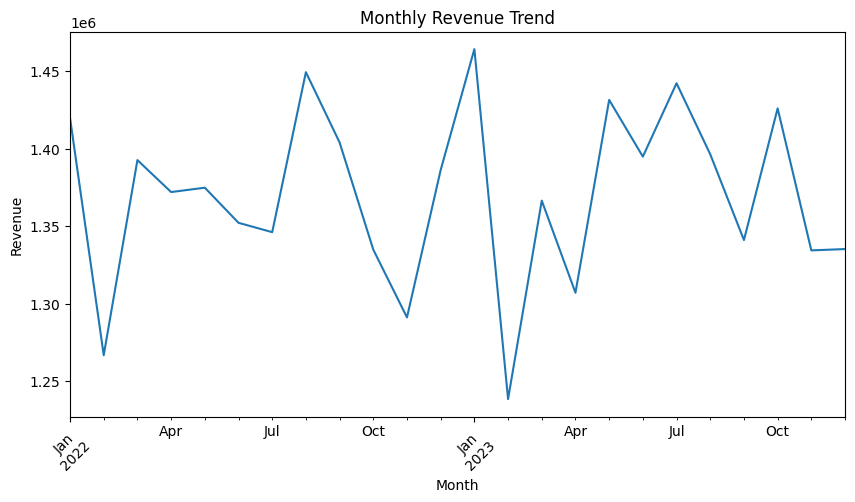

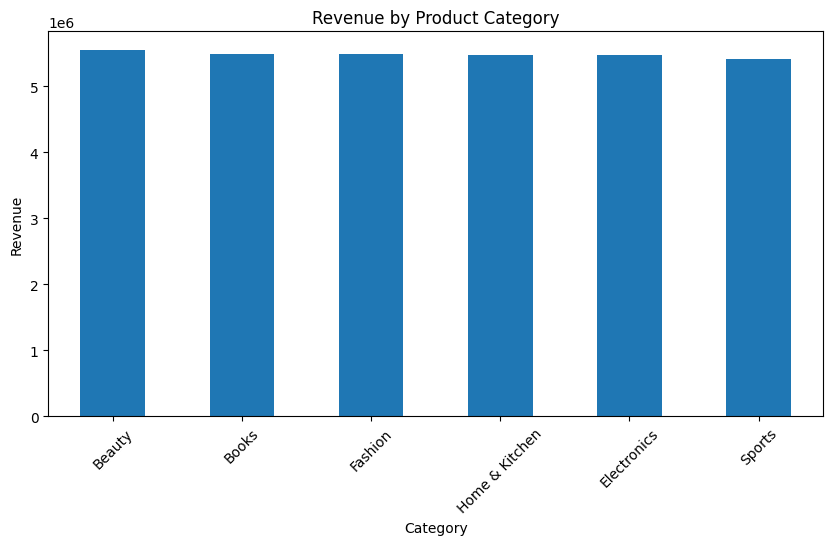

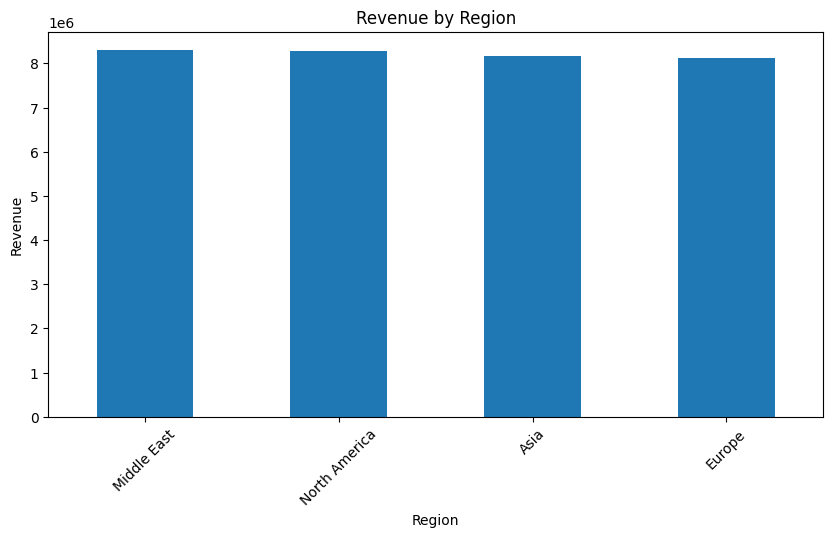

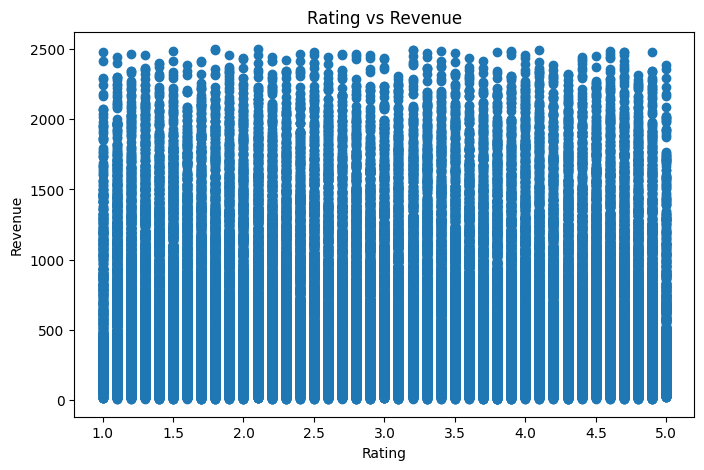


MODEL PERFORMANCE
R2 Score: 1.0
MAE: 0.12

Top Business Drivers:
discounted_price                 5.478601e-01
quantity_sold                    4.521336e-01
price                            5.983145e-06
review_count                     7.037709e-08
product_id                       6.872558e-08
rating                           6.072362e-08
discount_percent                 2.194573e-08
customer_region_Europe           1.259771e-08
customer_region_North America    1.179288e-08
customer_region_Middle East      1.142866e-08
dtype: float64


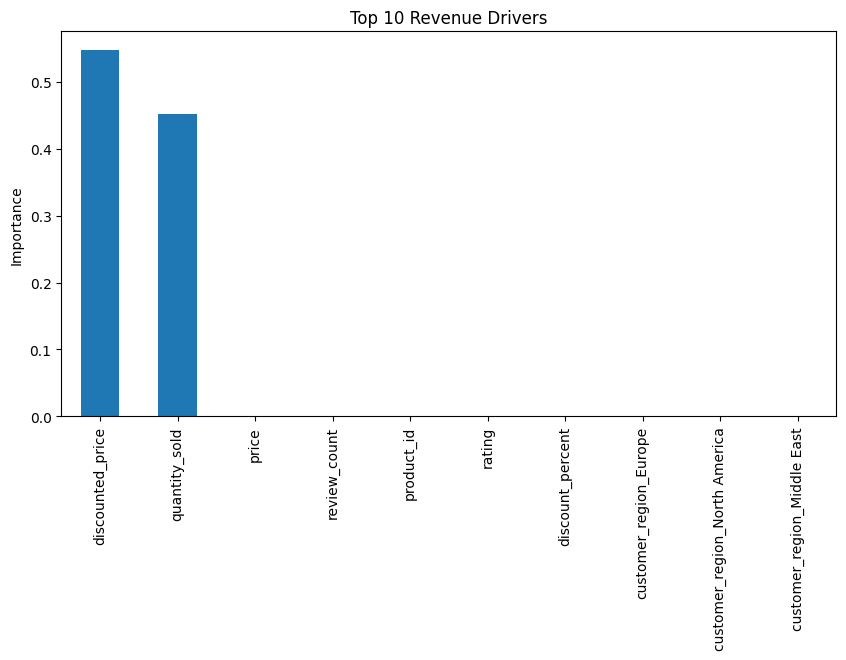

In [ ]:
# =========================
# AMAZON SALES ANALYTICS PROJECT
# Business Analyst | SQL style insights + Python + ML
# =========================

# Install / import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# -------------------------
# LOAD DATASET
# -------------------------
df = pd.read_csv("amazon_sales_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

# -------------------------
# DATA CLEANING
# -------------------------
df['order_date'] = pd.to_datetime(df['order_date'])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# -------------------------
# BUSINESS INSIGHTS
# -------------------------

# 1. Total Revenue
total_revenue = df['total_revenue'].sum()
print("\nTotal Revenue:", total_revenue)

# 2. Category-wise Revenue
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
print("\nCategory Revenue:")
print(category_revenue)

# 3. Region-wise Revenue
region_revenue = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)
print("\nRegion Revenue:")
print(region_revenue)

# 4. Payment Method Analysis
payment_revenue = df.groupby('payment_method')['total_revenue'].sum()
print("\nPayment Method Revenue:")
print(payment_revenue)

# -------------------------
# VISUALIZATIONS
# -------------------------

# Monthly Revenue Trend
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Category Revenue
plt.figure(figsize=(10,5))
category_revenue.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Region Revenue
plt.figure(figsize=(10,5))
region_revenue.plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Rating vs Revenue
plt.figure(figsize=(8,5))
plt.scatter(df['rating'], df['total_revenue'])
plt.title("Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue")
plt.show()

# -------------------------
# MACHINE LEARNING
# Revenue Prediction
# -------------------------

X = df.drop(['total_revenue', 'order_id', 'order_date'], axis=1)
y = df['total_revenue']

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("\nMODEL PERFORMANCE")
print("R2 Score:", round(r2, 3))
print("MAE:", round(mae, 2))

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Business Drivers:")
print(importance.head(10))

plt.figure(figsize=(10,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Revenue Drivers")
plt.ylabel("Importance")
plt.show()

In [ ]:
discount_efficiency = df.groupby("product_category").agg({
    "discount_percent":"mean",
    "total_revenue":"sum"
}).sort_values("discount_percent", ascending=False)

print(discount_efficiency)

                  discount_percent  total_revenue
product_category                                 
Sports                   13.406534     5407235.82
Beauty                   13.371530     5550624.97
Fashion                  13.358637     5480123.34
Books                    13.337336     5484863.03
Home & Kitchen           13.311334     5473132.55
Electronics              13.258413     5470594.03


In [ ]:
low_rating = df[df["rating"] < 3.5]
print(low_rating.groupby("product_category")["total_revenue"].sum())

product_category
Beauty            3430612.01
Books             3230430.10
Electronics       3341121.02
Fashion           3385785.66
Home & Kitchen    3361629.85
Sports            3295579.70
Name: total_revenue, dtype: float64


In [ ]:
low_rating = df[df["rating"] < 3.5]
print(low_rating.groupby("product_category")["total_revenue"].sum())

product_category
Beauty            3430612.01
Books             3230430.10
Electronics       3341121.02
Fashion           3385785.66
Home & Kitchen    3361629.85
Sports            3295579.70
Name: total_revenue, dtype: float64


In [ ]:
at_risk = df[
    (df["rating"] < 3.5) |
    (df["discount_percent"] > 40)
]

revenue_at_risk = at_risk["total_revenue"].sum()

print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 20045158.34


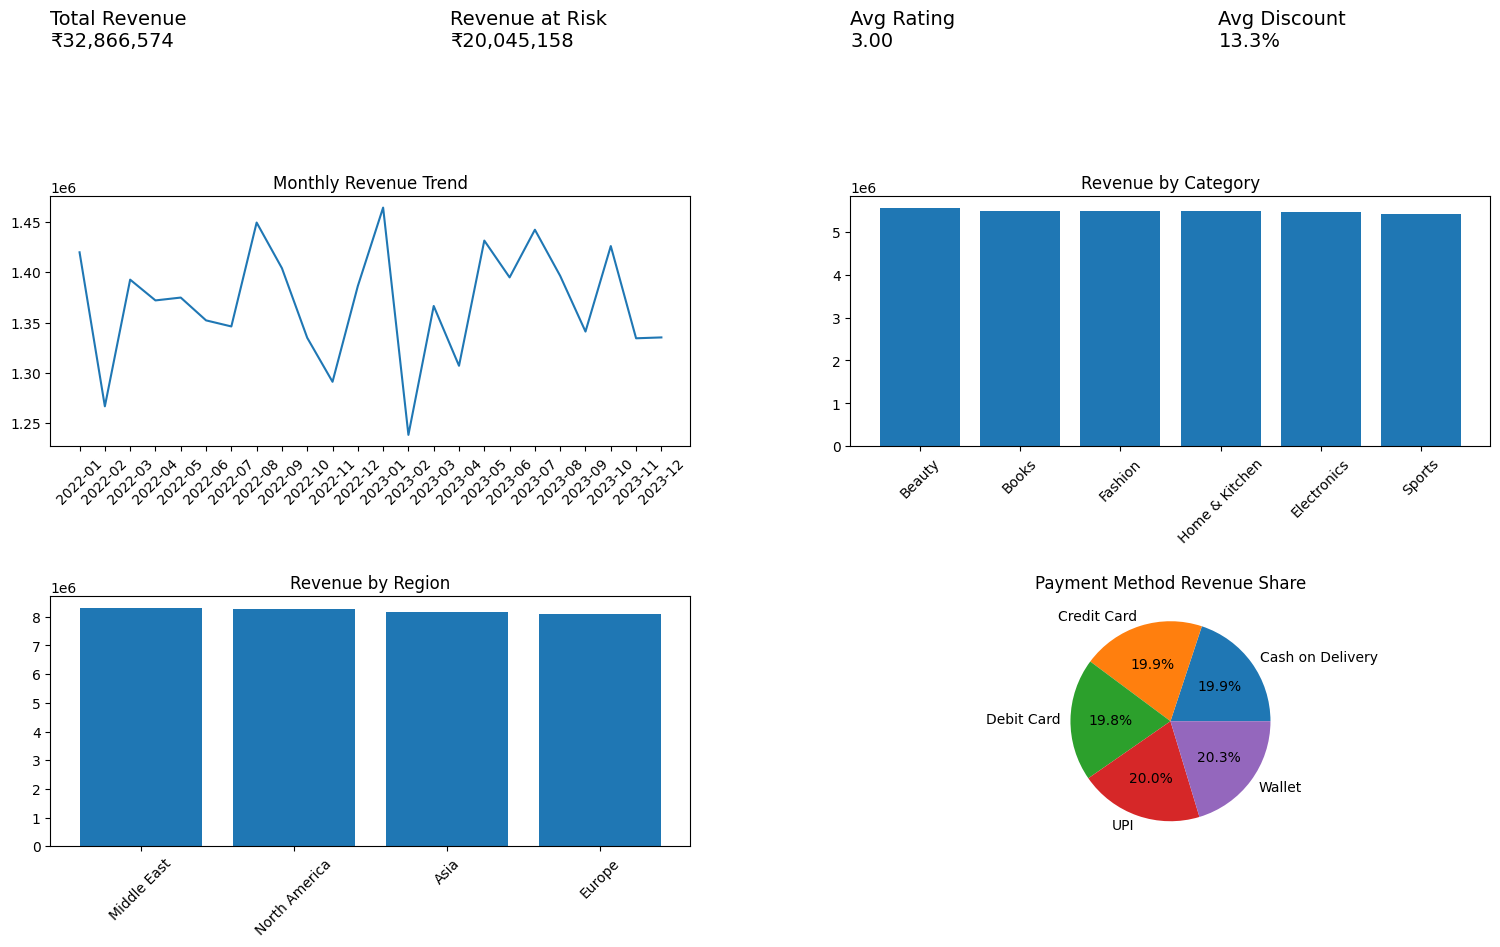

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("amazon_sales_dataset.csv")
df["order_date"] = pd.to_datetime(df["order_date"])

# KPIs
total_revenue = df["total_revenue"].sum()
avg_rating = df["rating"].mean()
avg_discount = df["discount_percent"].mean()

at_risk = df[
    (df["rating"] < 3.5) |
    (df["discount_percent"] > 40)
]
revenue_at_risk = at_risk["total_revenue"].sum()

# Aggregations
monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["total_revenue"].sum()

category_revenue = df.groupby(
    "product_category"
)["total_revenue"].sum().sort_values(ascending=False)

region_revenue = df.groupby(
    "customer_region"
)["total_revenue"].sum().sort_values(ascending=False)

payment_share = df.groupby(
    "payment_method"
)["total_revenue"].sum()

# -------------------------
# DASHBOARD LAYOUT
# -------------------------
fig = plt.figure(figsize=(16,10))

# KPI section
fig.text(0.05, 0.95, f"Total Revenue\n₹{total_revenue:,.0f}", fontsize=14)
fig.text(0.30, 0.95, f"Revenue at Risk\n₹{revenue_at_risk:,.0f}", fontsize=14)
fig.text(0.55, 0.95, f"Avg Rating\n{avg_rating:.2f}", fontsize=14)
fig.text(0.78, 0.95, f"Avg Discount\n{avg_discount:.1f}%", fontsize=14)

# Monthly trend
ax1 = plt.axes([0.05, 0.55, 0.4, 0.25])
ax1.plot(monthly_sales.index.astype(str), monthly_sales.values)
ax1.set_title("Monthly Revenue Trend")
ax1.tick_params(axis='x', rotation=45)

# Category revenue
ax2 = plt.axes([0.55, 0.55, 0.4, 0.25])
ax2.bar(category_revenue.index, category_revenue.values)
ax2.set_title("Revenue by Category")
ax2.tick_params(axis='x', rotation=45)

# Region revenue
ax3 = plt.axes([0.05, 0.15, 0.4, 0.25])
ax3.bar(region_revenue.index, region_revenue.values)
ax3.set_title("Revenue by Region")
ax3.tick_params(axis='x', rotation=45)

# Payment method share
ax4 = plt.axes([0.55, 0.15, 0.4, 0.25])
ax4.pie(payment_share.values, labels=payment_share.index, autopct='%1.1f%%')
ax4.set_title("Payment Method Revenue Share")

plt.show()

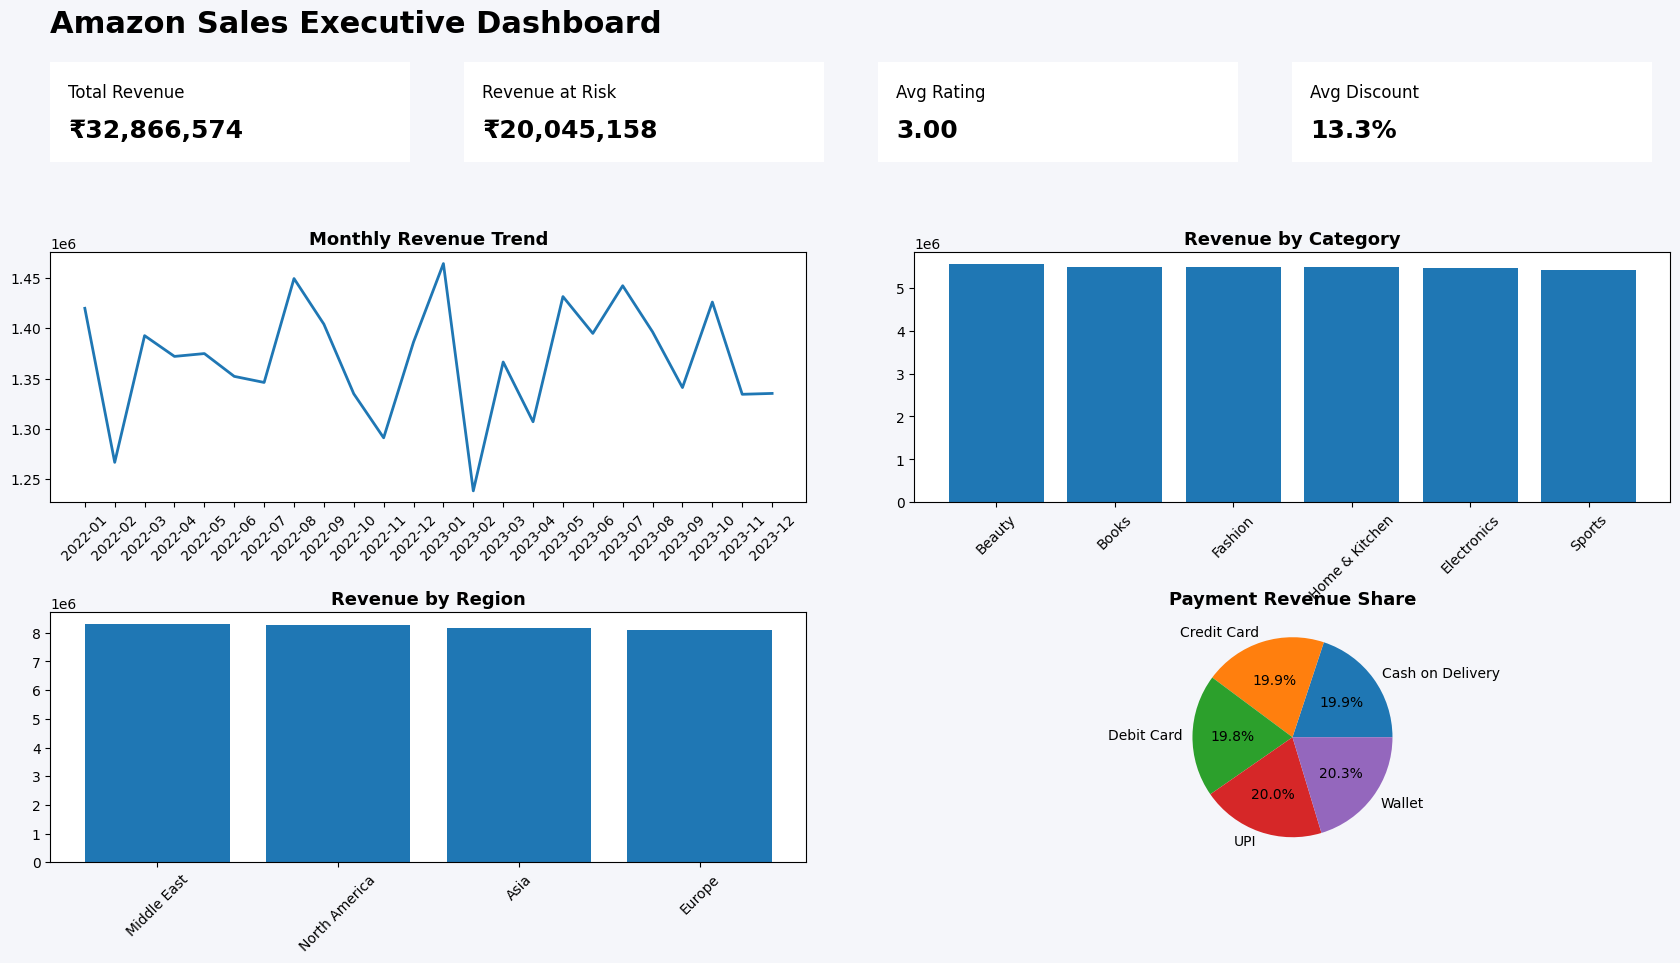

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("amazon_sales_dataset.csv")
df["order_date"] = pd.to_datetime(df["order_date"])

# -------------------------
# KPI CALCULATIONS
# -------------------------
total_revenue = df["total_revenue"].sum()
avg_rating = df["rating"].mean()
avg_discount = df["discount_percent"].mean()
total_orders = df["order_id"].nunique()

at_risk = df[
    (df["rating"] < 3.5) |
    (df["discount_percent"] > 40)
]
revenue_at_risk = at_risk["total_revenue"].sum()

monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["total_revenue"].sum()

category_revenue = df.groupby(
    "product_category"
)["total_revenue"].sum().sort_values(ascending=False)

region_revenue = df.groupby(
    "customer_region"
)["total_revenue"].sum().sort_values(ascending=False)

payment_share = df.groupby(
    "payment_method"
)["total_revenue"].sum()

# -------------------------
# FIGURE
# -------------------------
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor("#f5f6fa")

# Title
fig.text(0.05, 0.95, "Amazon Sales Executive Dashboard",
         fontsize=22, fontweight='bold')

# -------------------------
# KPI CARDS
# -------------------------
cards = [
    ("Total Revenue", f"₹{total_revenue:,.0f}", 0.05),
    ("Revenue at Risk", f"₹{revenue_at_risk:,.0f}", 0.28),
    ("Avg Rating", f"{avg_rating:.2f}", 0.51),
    ("Avg Discount", f"{avg_discount:.1f}%", 0.74)
]

for title, value, x in cards:
    ax = fig.add_axes([x, 0.82, 0.2, 0.1])
    ax.axis("off")
    box = FancyBboxPatch(
        (0,0),1,1,
        boxstyle="round,pad=0.02",
        linewidth=1,
        edgecolor="#dcdde1",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(0.05, 0.65, title, fontsize=12)
    ax.text(0.05, 0.25, value, fontsize=18, fontweight="bold")

# -------------------------
# MONTHLY TREND
# -------------------------
ax1 = fig.add_axes([0.05, 0.48, 0.42, 0.25])
ax1.set_facecolor("white")
ax1.plot(monthly_sales.index.astype(str), monthly_sales.values, linewidth=2)
ax1.set_title("Monthly Revenue Trend", fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# -------------------------
# CATEGORY BAR
# -------------------------
ax2 = fig.add_axes([0.53, 0.48, 0.42, 0.25])
ax2.set_facecolor("white")
ax2.bar(category_revenue.index, category_revenue.values)
ax2.set_title("Revenue by Category", fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# -------------------------
# REGION BAR
# -------------------------
ax3 = fig.add_axes([0.05, 0.12, 0.42, 0.25])
ax3.set_facecolor("white")
ax3.bar(region_revenue.index, region_revenue.values)
ax3.set_title("Revenue by Region", fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# -------------------------
# PAYMENT PIE
# -------------------------
ax4 = fig.add_axes([0.53, 0.12, 0.42, 0.25])
ax4.set_facecolor("white")
ax4.pie(payment_share.values,
        labels=payment_share.index,
        autopct='%1.1f%%')
ax4.set_title("Payment Revenue Share", fontsize=13, fontweight='bold')

plt.show()